# Assignment 5 Shape and Texture Features for Classification

**Student Name:** Sheylle Green and Marc Wijnands  
**Group Number:** 20

In [82]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import glob
from skimage.feature import hog
from skimage.transform import resize
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import binary_closing, binary_fill_holes
from skimage.feature import hog
from skimage.transform import resize as sk_resize
from skimage.color import rgb2gray

---
## Part 1 Segmentation

In [99]:
IMAGE_DIR = './images/'
all_files = sorted(glob.glob(os.path.join(IMAGE_DIR, 'w8t1t2_d7_*.tif')))
print(f'Found {len(all_files)} total tif files')

# Separate main, b and c files
main_files = [f for f in all_files
              if not os.path.basename(f).replace('.tif','').endswith(('b', 'c'))]
b_files = [f for f in all_files
              if os.path.basename(f).replace('.tif','').endswith('b')]
c_files = [f for f in all_files
             if os.path.basename(f).replace('.tif','').endswith('c')]
print(f'Main files: {len(main_files)}, B files: {len(b_files)}, C files: {len(c_files)}')

main_basenames = set(os.path.basename(f) for f in main_files)
# Include b only if no main exists
for bf in b_files:
    main_equiv = os.path.basename(bf).replace('b.tif', '.tif')
    if main_equiv not in main_basenames:
        main_files.append(bf)
        main_basenames.add(os.path.basename(bf))  # track it so c doesn't also get added
# Include c only if neither main nor b exists
for cf in c_files:
    main_equiv = os.path.basename(cf).replace('c.tif', '.tif')
    b_equiv    = os.path.basename(cf).replace('c.tif', 'b.tif')
    if main_equiv not in main_basenames and b_equiv not in main_basenames:
        main_files.append(cf)

image_files = sorted(main_files)
image_files = [f.replace('\\', '/') for f in image_files]

print(f'Total after deduplication: {len(image_files)}')


Found 77 total tif files
Main files: 58, B files: 17, C files: 2
Total after deduplication: 58


### Part 1.1 Segmentation Pipeline

**Procedure:**

1. **Load image:** RGB uint16 via `dip.ImageRead`; grayscale copy made for thresholding.
2. **Gaussian smoothing** (`dip.Gauss`, σ = 2 px): noise reduction.
3. **Otsu thresholding** (`dip.Threshold`): separates the bright embryo body from the dark background.
4. **Blue detection** (HSV colour space, hue 0.40–0.75): captures dark blue stained regions that fall below the Otsu threshold due to low brightness.
5. **Combine:** foreground = Otsu mask OR blue mask, ensuring both bright and dark-stained tissue are included.
6. **Morphological closing** (25×25 SE) + **hole filling**: bridges gaps and fills transparent internal regions.
7. **Largest connected component:** retains only the embryo, discarding background debris.

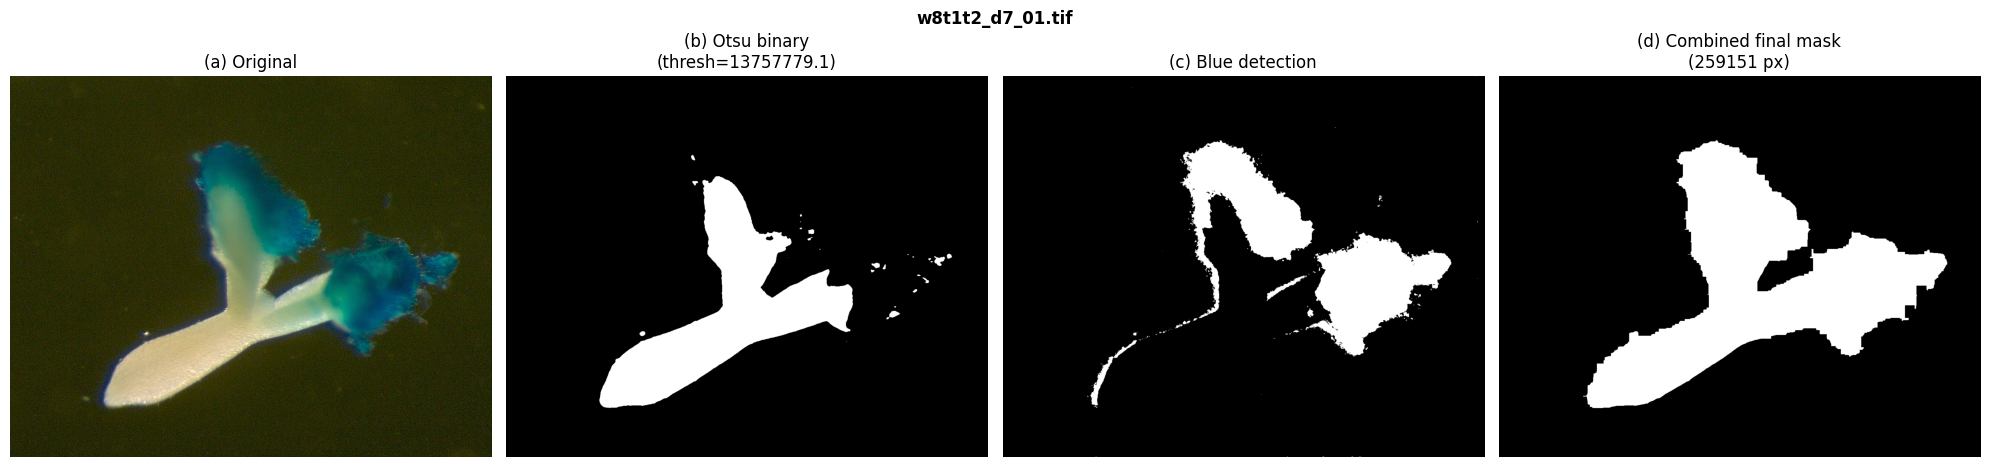

Image shape: (1030, 1300, 3)
Mask coverage: 259151 px (19.4% of image)


In [ ]:
def stretch(arr):
    a, b = arr.min(), arr.max()
    return (arr - a) / (b - a) if b > a else arr.astype(float)


def segment_embryo(filepath, plot=False):
    filepath = filepath.replace('\\', '/')
    img = dip.ImageRead(filepath)
    img_rgb  = np.array(img)

    # Convert to grayscale
    if img.TensorElements() > 1:
        grey = dip.ColorSpaceManager.Convert(img, 'gray')
    else:
        grey = img

    # Step 1: Smooth
    smoothed = dip.Gauss(grey, [2])
    # Step 2: Otsu threshold, catches bright embryo body
    binary, thresh = dip.Threshold(smoothed)
    binary_arr = np.array(binary).astype(bool)
    # Step 3: Also detect blue pixels... catches dark blue missed by Otsu
    from skimage.color import rgb2hsv
    maxval = 65535.0 if img_rgb.dtype == np.uint16 else 255.0
    rgb_f = img_rgb.astype(float) / maxval
    hsv = rgb2hsv(rgb_f)
    H,S,V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    R,B = rgb_f[:,:,0], rgb_f[:,:,2]
    sat_threshold = np.where(V < 0.2, 0.06, 0.12)
    blue_arr = (
    (H >= 0.42) & (H <= 0.72) & (S >= 0.20) & (V >= 0.08) & (V <= 0.92) & (B >= R + 0.02) )
    # Step 4: Combine embryo = bright pixels OR blue pixels
    combined = binary_arr | blue_arr
    # Step 5: Close holes (larger SE to bridge gaps between bright and blue regions)
    struct = np.ones((25, 25))
    closed = binary_closing(combined, structure=struct)
    filled = binary_fill_holes(closed)
    # Step 6: Keep only largest connected component
    from scipy.ndimage import label as scipy_label
    labeled_np,n = scipy_label(filled)
    if n == 0:
        return img_rgb, np.zeros(filled.shape, dtype=bool), None
    sizes = [(labeled_np == i).sum() for i in range(1, n + 1)]
    largest = np.argmax(sizes) + 1
    mask = (labeled_np == largest)

    if plot:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes[0].imshow(stretch(img_rgb.astype(float)))
        axes[0].set_title('(a) Original')
        axes[0].axis('off')
        axes[1].imshow(binary_arr, cmap='gray')
        axes[1].set_title(f'(b) Otsu binary\n(thresh={float(thresh):.1f})')
        axes[1].axis('off')
        axes[2].imshow(blue_arr, cmap='gray')
        axes[2].set_title('(c) Blue detection')
        axes[2].axis('off')
        axes[3].imshow(mask, cmap='gray')
        axes[3].set_title(f'(d) Combined final mask\n({mask.sum()} px)')
        axes[3].axis('off')
        plt.suptitle(os.path.basename(filepath), fontweight='bold')
        plt.tight_layout()
        plt.show()

    return img_rgb, mask, labeled_np

# test.
if len(image_files) > 0:
    test_rgb, test_mask, test_labeled = segment_embryo(image_files[0], plot=True)
    print(f'Image shape: {test_rgb.shape}')
    print(f'Mask coverage: {test_mask.sum()} px ({100*test_mask.mean():.1f}% of image)')

In [101]:
# Segment all images 
results = {}  # {filename: {'rgb': arr, 'mask': arr}}

for filepath in image_files:
    name = os.path.splitext(os.path.basename(filepath))[0]
    rgb, mask, labeled = segment_embryo(filepath)
    results[name] = {'rgb': rgb, 'mask': mask, 'filepath': filepath}
    print(f'{name}: mask={mask.sum()}px, shape={rgb.shape}')

print(f'\nTotal embryos segmented: {len(results)}')

w8t1t2_d7_01: mask=259151px, shape=(1030, 1300, 3)
w8t1t2_d7_02: mask=297027px, shape=(1030, 1300, 3)
w8t1t2_d7_03: mask=224921px, shape=(1030, 1300, 3)
w8t1t2_d7_04: mask=414372px, shape=(1030, 1300, 3)
w8t1t2_d7_05: mask=234943px, shape=(1030, 1300, 3)
w8t1t2_d7_06: mask=230292px, shape=(1030, 1300, 3)
w8t1t2_d7_07: mask=264806px, shape=(1030, 1300, 3)
w8t1t2_d7_08: mask=182021px, shape=(1030, 1300, 3)
w8t1t2_d7_09: mask=265493px, shape=(1030, 1300, 3)
w8t1t2_d7_10: mask=283765px, shape=(1030, 1300, 3)
w8t1t2_d7_11: mask=230533px, shape=(1030, 1300, 3)
w8t1t2_d7_12: mask=213870px, shape=(1030, 1300, 3)
w8t1t2_d7_13: mask=232290px, shape=(1030, 1300, 3)
w8t1t2_d7_14: mask=302277px, shape=(1030, 1300, 3)
w8t1t2_d7_15: mask=317032px, shape=(1030, 1300, 3)
w8t1t2_d7_16: mask=167322px, shape=(1030, 1300, 3)
w8t1t2_d7_17: mask=313867px, shape=(1030, 1300, 3)
w8t1t2_d7_18: mask=205328px, shape=(1030, 1300, 3)
w8t1t2_d7_19: mask=249790px, shape=(1030, 1300, 3)
w8t1t2_d7_20: mask=223329px, sh

### Part 1.2 — Panel of all original images (4×15 grid)

Total embryos to display: 58


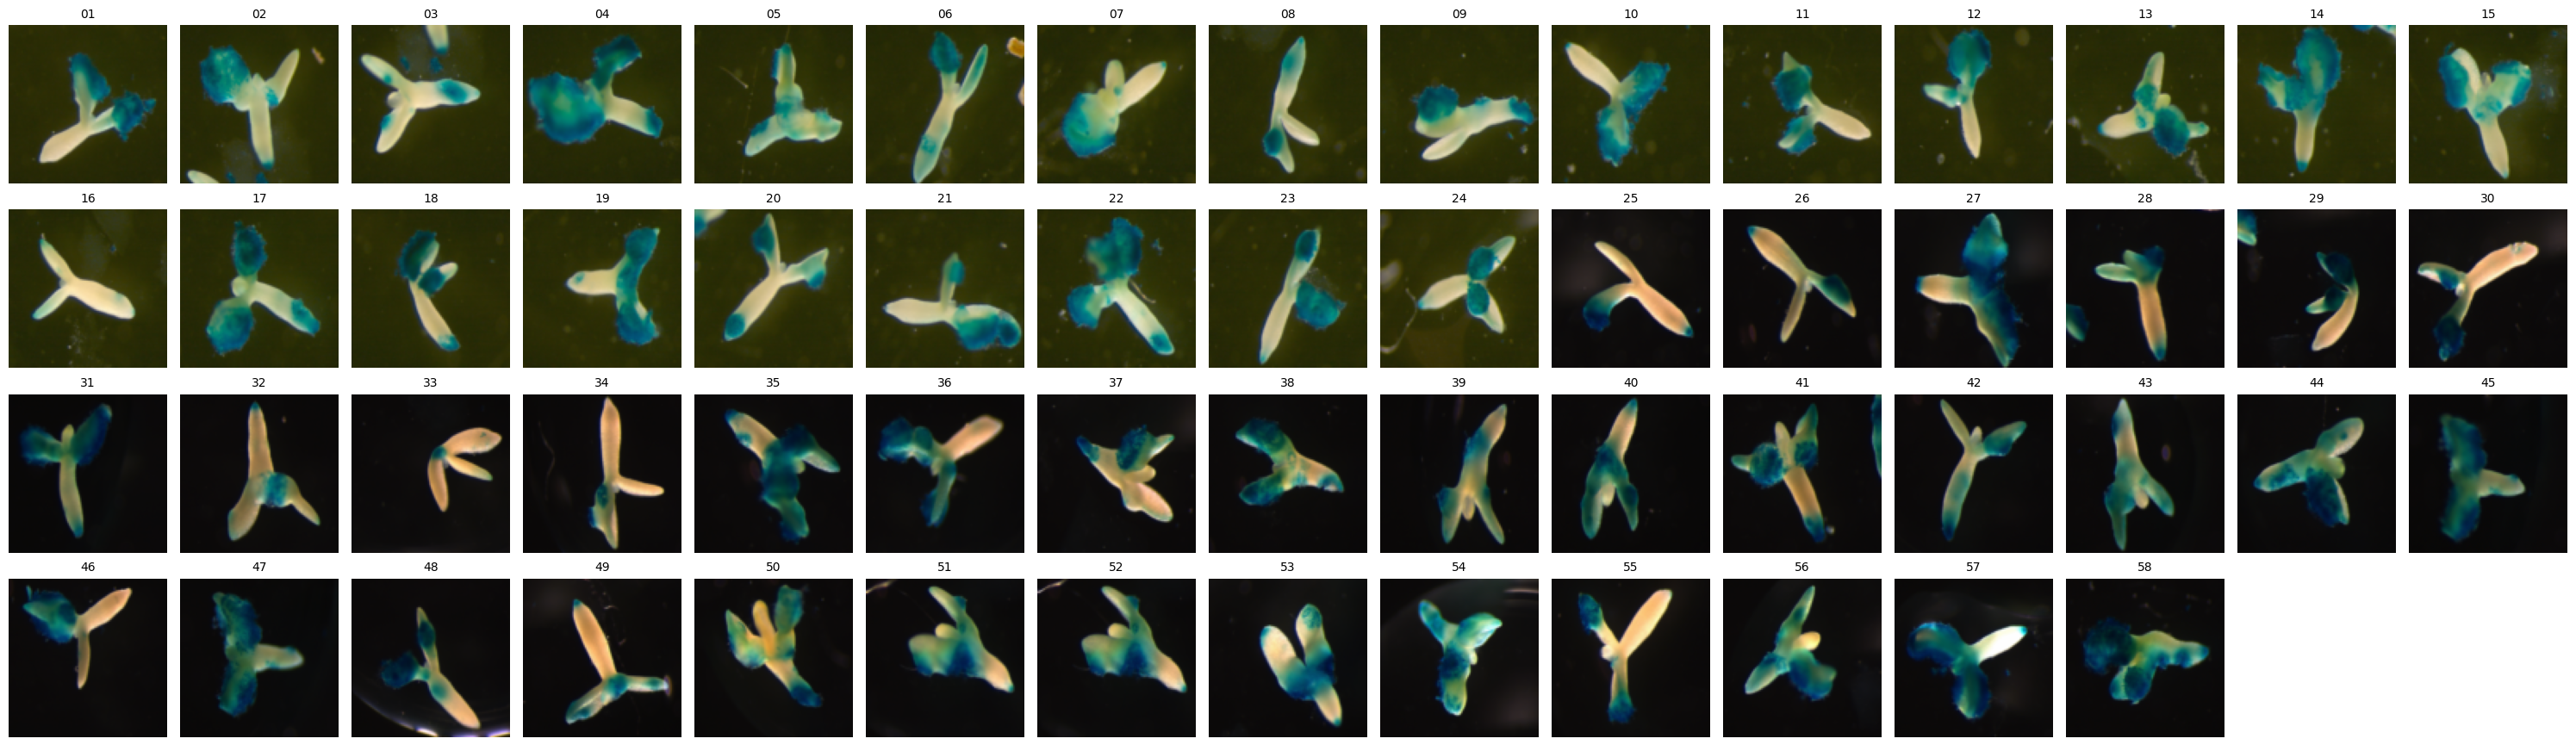

In [102]:
NCOLS = 15
NROWS = 4
PANEL_SIZE = 100  

names = list(results.keys())
print(f'Total embryos to display: {len(names)}')

fig,axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 2, NROWS * 2.2))

for idx, name in enumerate(names):
    row = idx // NCOLS
    col = idx  % NCOLS
    ax = axes[row, col]

    rgb = results[name]['rgb']
    rgb_display = stretch(rgb.astype(float))
    rgb_small = resize(rgb_display, (PANEL_SIZE, PANEL_SIZE), anti_aliasing=True)

    ax.imshow(rgb_small)
    ax.set_title(name.replace('w8t1t2_d7_', ''), fontsize=10)  # just show number
    ax.axis('off')

for idx in range(len(names), NROWS * NCOLS):
    axes[idx // NCOLS, idx % NCOLS].axis('off')

plt.tight_layout()
plt.savefig('panel_original.png', dpi=120, bbox_inches='tight')
plt.show()

### Part 1.3 — Panel of all binary segmentation masks

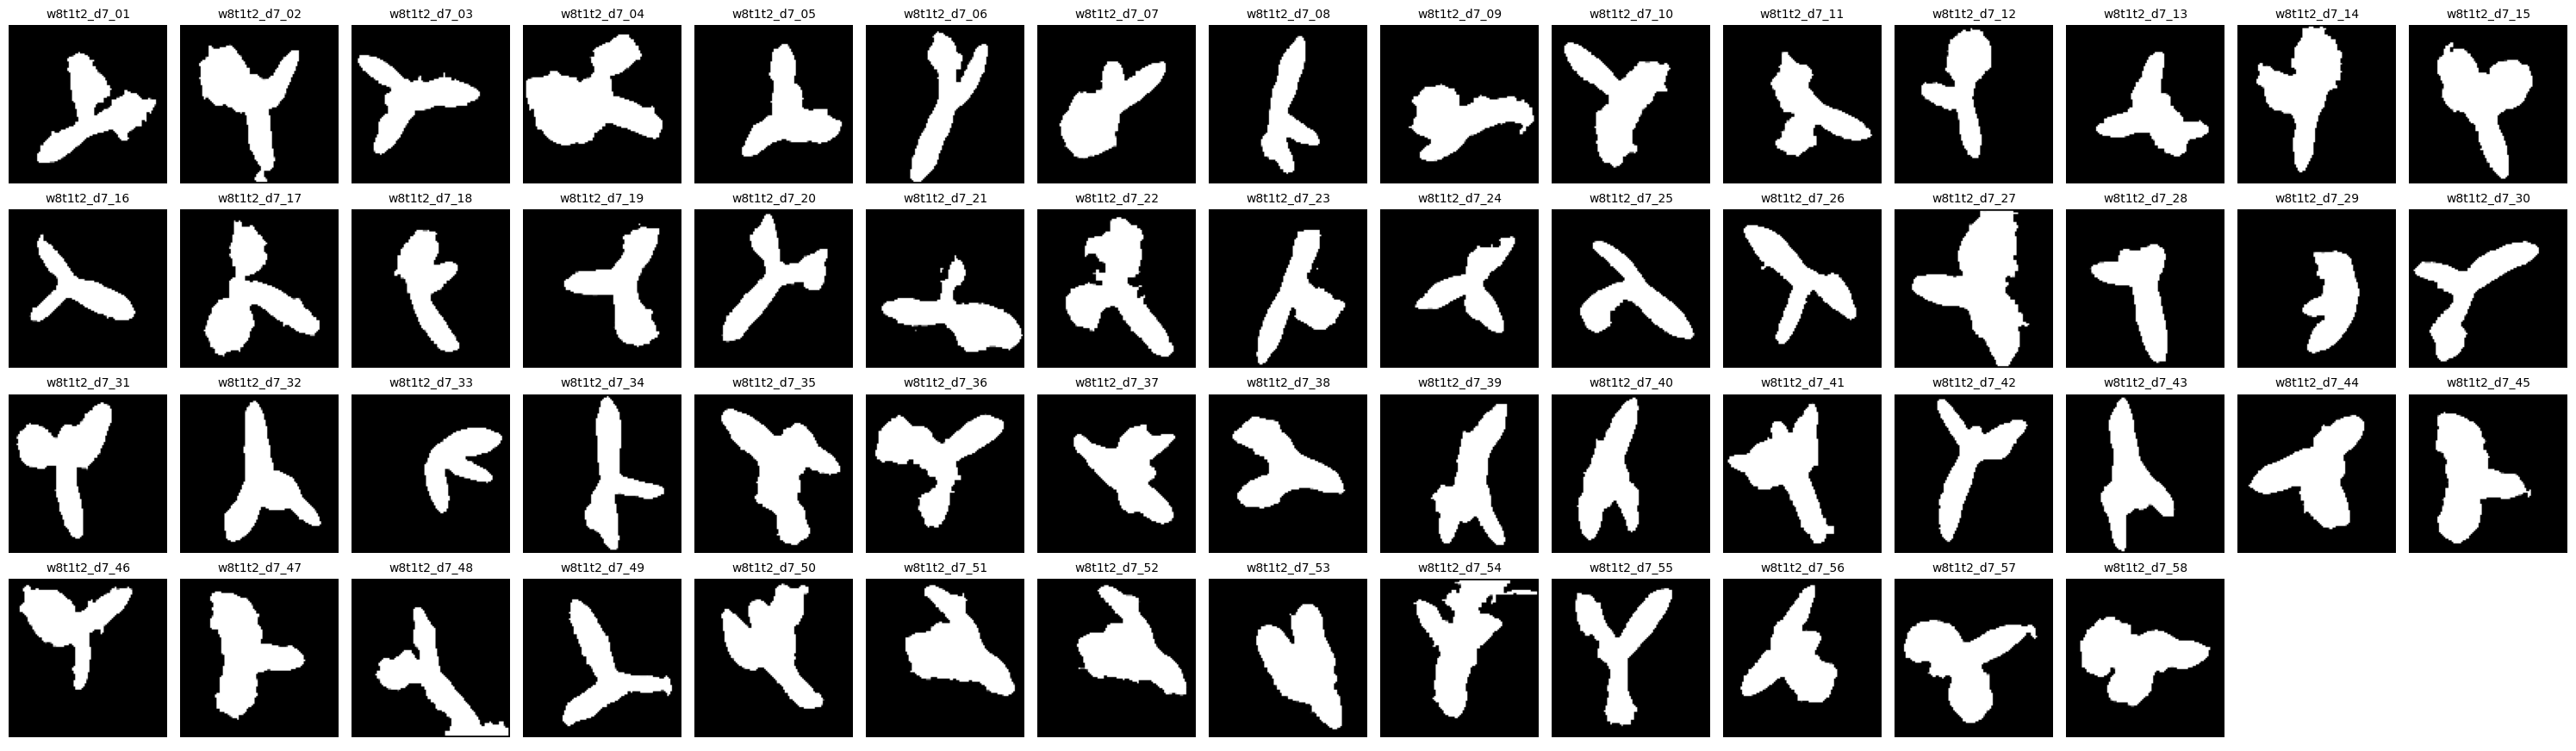

In [103]:
# Panel of all binary masks; same 4x15 layout
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 2, NROWS * 2.2))

for idx, name in enumerate(names):
    row = idx // NCOLS
    col = idx  % NCOLS
    ax = axes[row, col]

    mask = results[name]['mask']
    mask_small = resize(mask.astype(float), (PANEL_SIZE, PANEL_SIZE), anti_aliasing=False)

    ax.imshow(mask_small, cmap='gray', vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

for idx in range(len(names), NROWS * NCOLS):
    axes[idx // NCOLS, idx % NCOLS].axis('off')

plt.tight_layout()
plt.savefig('panel_binary.png', dpi=100, bbox_inches='tight')
plt.show()


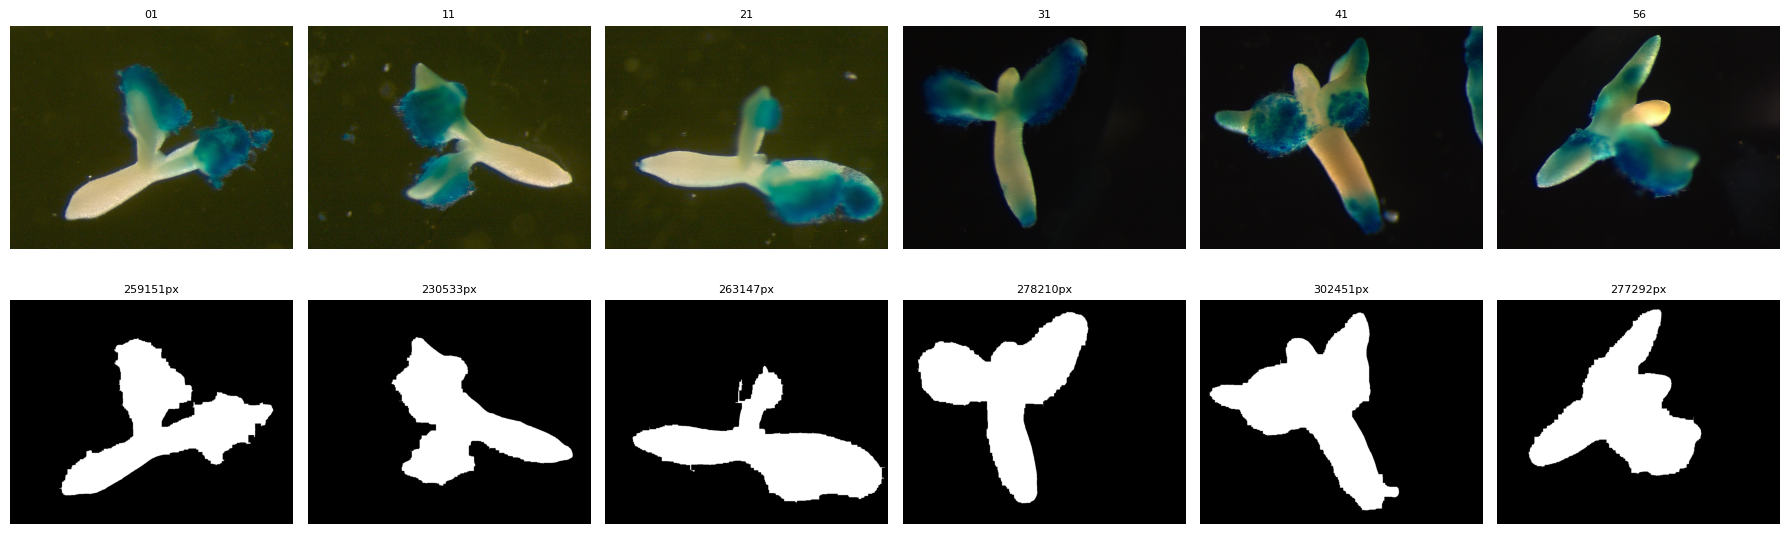

In [104]:

check_names = [names[i] for i in [0, 10, 20, 30, 40, 55]]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for col, name in enumerate(check_names):
    rgb = results[name]['rgb']
    mask = results[name]['mask']

    axes[0, col].imshow(stretch(rgb.astype(float)))
    axes[0, col].set_title(name.replace('w8t1t2_d7_', ''), fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(mask, cmap='gray')
    axes[1, col].set_title(f'{mask.sum():.0f}px', fontsize=8)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

---
## Part 2 Shape, Size and Blue Expression Measurements

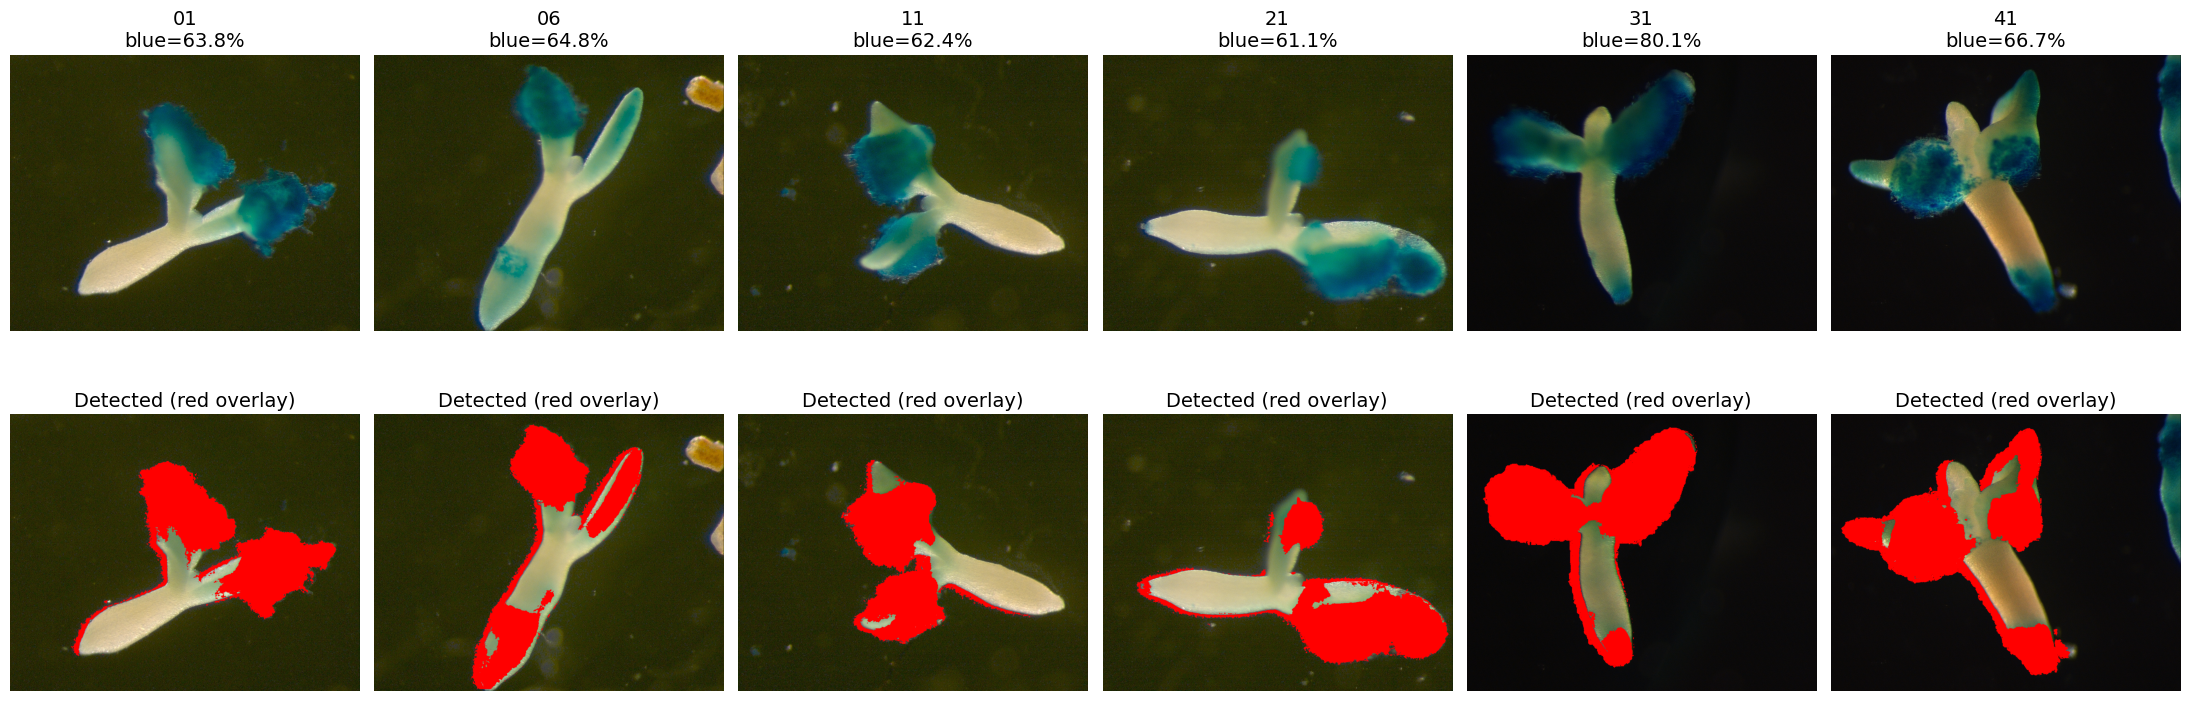

In [105]:
def detect_blue(rgb, embryo_mask):

    if rgb.ndim == 2:
        return np.zeros(rgb.shape, dtype=bool)

    from skimage.color import rgb2hsv
    from scipy.ndimage import binary_dilation

    maxval = 65535.0 if rgb.dtype == np.uint16 else 255.0
    rgb_f = rgb.astype(float) / maxval
    hsv = rgb2hsv(rgb_f)
    H = hsv[:,:,0]
    S = hsv[:,:,1]
    V = hsv[:,:,2]
    R = rgb_f[:,:,0]
    B = rgb_f[:,:,2]

    dilated_mask = binary_dilation(embryo_mask, iterations=5)
    sat_threshold = np.where(V < 0.2, 0.06, 0.12)

    blue_mask = ( (H >= 0.30) & (H <= 0.75) & (S >= sat_threshold) & (V >= 0.02) & (V <= 0.97) & (B >= R - 0.05)) & dilated_mask

    return blue_mask

# Visual check
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
check_names = [names[i] for i in [0, 5, 10, 20, 30, 40]]

for col, name in enumerate(check_names):
    rgb = results[name]['rgb']
    mask = results[name]['mask']
    blue_mask = detect_blue(rgb, mask)

    axes[0, col].imshow(stretch(rgb.astype(float)))
    axes[0, col].set_title(f'{name.replace("w8t1t2_d7_","")}\n' f'blue={100*blue_mask.sum()/max(mask.sum(),1):.1f}%', fontsize=14)
    axes[0, col].axis('off')
    
    overlay = stretch(rgb.astype(float)).copy()
    overlay[blue_mask] = [1, 0, 0]
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('Detected (red overlay)', fontsize=14)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

### Part 2.1 — Compute shape, size and blue expression features

In [107]:
def compute_shape_features(mask):

    area = float(mask.sum())
    if area == 0:
        return {'area': 0, 'perimeter': 0, 'roundness': 0, 'solidity': 0}

    #Perimeter: boundary pixels
    eroded = ndimage.binary_erosion(mask)
    boundary = mask & ~eroded
    perim = float(boundary.sum())

    #Roundness
    roundness = float((4 * np.pi * area) / (perim ** 2)) if perim > 0 else 0.0

    # Solidity via convex hull
    try:
        coords = np.column_stack(np.where(mask))
        if len(coords) > 2000:
            idx = np.random.choice(len(coords), 2000, replace=False)
            coords = coords[idx]
        hull = ConvexHull(coords)
        solidity = area / hull.volume if hull.volume > 0 else 0.0
    except Exception:
        solidity = 0.0

    return {'area': area, 'perimeter': perim, 'roundness': roundness, 'solidity': solidity}


def compute_blue_features(rgb, embryo_mask):

    blue_mask = detect_blue(rgb, embryo_mask)
    area = max(embryo_mask.sum(), 1)
    abs_blue = float(blue_mask.sum())
    rel_blue = abs_blue / area
    return {'abs_blue': abs_blue, 'rel_blue': rel_blue, 'blue_mask': blue_mask}

rows = []
for name in names:
    rgb = results[name]['rgb']
    mask = results[name]['mask']
    shape = compute_shape_features(mask)
    blue = compute_blue_features(rgb, mask)

    results[name]['blue_mask'] = blue['blue_mask']
    results[name]['features'] = {**shape, 'abs_blue': blue['abs_blue'], 'rel_blue': blue['rel_blue']}
    rows.append({'embryo': name, **shape, 'abs_blue': blue['abs_blue'], 'rel_blue': round(blue['rel_blue'], 4)})

    print(f'{name}: area={shape["area"]:.0f}, perim={shape["perimeter"]:.0f}, 'f'round={shape["roundness"]:.3f}, solid={shape["solidity"]:.3f}, 'f'blue={100*blue["rel_blue"]:.1f}%')

df_features = pd.DataFrame(rows).set_index('embryo')
print('\nFeature table:')
print(df_features.round(3).to_string())

w8t1t2_d7_01: area=259151, perim=3897, round=0.214, solid=0.649, blue=63.8%
w8t1t2_d7_02: area=297027, perim=3630, round=0.283, solid=0.636, blue=57.2%
w8t1t2_d7_03: area=224921, perim=3202, round=0.276, solid=0.616, blue=37.4%
w8t1t2_d7_04: area=414372, perim=4263, round=0.287, solid=0.725, blue=86.5%
w8t1t2_d7_05: area=234943, perim=2836, round=0.367, solid=0.690, blue=67.3%
w8t1t2_d7_06: area=230292, perim=3283, round=0.269, solid=0.709, blue=64.8%
w8t1t2_d7_07: area=264806, perim=2746, round=0.441, solid=0.829, blue=51.9%
w8t1t2_d7_08: area=182021, perim=2684, round=0.318, solid=0.681, blue=50.6%
w8t1t2_d7_09: area=265493, perim=3236, round=0.319, solid=0.771, blue=51.9%
w8t1t2_d7_10: area=283765, perim=3446, round=0.300, solid=0.684, blue=72.7%
w8t1t2_d7_11: area=230533, perim=3046, round=0.312, solid=0.717, blue=62.4%
w8t1t2_d7_12: area=213870, perim=2906, round=0.318, solid=0.718, blue=75.6%
w8t1t2_d7_13: area=232290, perim=2959, round=0.333, solid=0.684, blue=64.1%
w8t1t2_d7_14

### Part 2.2 Establish three groups

In [108]:
# APPROACH:
#   Group 0: Small embryos with little/no blue expression
#   Group 1: Medium embryos with moderate blue expression  
#   Group 2: Large embryos with high blue expression
#
# We use area and relative blue as the two primary features.
# Thresholds are set at the 33rd and 66th percentiles (tertiles)
# which naturally splits 60 embryos into ~20 per group.

areas = df_features['area'].values
rel_blues = df_features['rel_blue'].values

# Print distribution to understand the data
print(f'Area: min={areas.min():.0f}, 'f'median={np.median(areas):.0f}, 'f'max={areas.max():.0f}')
print(f'Rel blue: min={rel_blues.min():.3f}, ' f'median={np.median(rel_blues):.3f}, 'f'max={rel_blues.max():.3f}')
print(f'Roundness: min={df_features["roundness"].min():.3f}, 'f'median={np.median(df_features["roundness"]):.3f}, 'f'max={df_features["roundness"].max():.3f}')

# --- Thresholds at tertiles ---
AREA_T1 = np.percentile(areas, 33)
AREA_T2 = np.percentile(areas, 66)
BLUE_T1 = np.percentile(rel_blues, 33)
BLUE_T2 = np.percentile(rel_blues, 66)

print(f'\nArea tertiles: T1={AREA_T1:.0f}, T2={AREA_T2:.0f}')
print(f'Blue tertiles: T1={BLUE_T1:.3f}, T2={BLUE_T2:.3f}')

def assign_group(area, rel_blue):

    if rel_blue <= BLUE_T1:
        return 0   # low blue 
    elif rel_blue >= BLUE_T2:
        return 2   # high blue 
    else:
        return 1   # moderate blue 

df_features['group'] = [
    assign_group(r['area'], r['rel_blue'])
    for _, r in df_features.iterrows()
]

# Store in results dict
for name in names:
    results[name]['group'] = int(df_features.loc[name, 'group'])

print('\nGroup distribution')
print(df_features['group'].value_counts().sort_index())
print(f'\nGroup 0 (low blue):    {(df_features["group"]==0).sum()} embryos')
print(f'Group 1 (moderate):    {(df_features["group"]==1).sum()} embryos')
print(f'Group 2 (high blue):   {(df_features["group"]==2).sum()} embryos')

print('\nEmbryos per group')
for g in [0, 1, 2]:
    members = df_features[df_features['group'] == g].index.tolist()
    print(f'Group {g}: {[m.replace("w8t1t2_d7_","") for m in members]}')

Area: min=167322, median=262395, max=442109
Rel blue: min=0.208, median=0.661, max=0.931
Roundness: min=0.156, median=0.317, max=0.474

Area tertiles: T1=238764, T2=291987
Blue tertiles: T1=0.609, T2=0.714

Group distribution
group
0    19
1    19
2    20
Name: count, dtype: int64

Group 0 (low blue):    19 embryos
Group 1 (moderate):    19 embryos
Group 2 (high blue):   20 embryos

Embryos per group
Group 0: ['02', '03', '07', '08', '09', '16', '20', '24', '25', '26', '30', '32', '33', '34', '37', '39', '49', '50', '55']
Group 1: ['01', '05', '06', '11', '13', '15', '18', '21', '23', '28', '29', '36', '41', '42', '46', '48', '51', '52', '53']
Group 2: ['04', '10', '12', '14', '17', '19', '22', '27', '31', '35', '38', '40', '43', '44', '45', '47', '54', '56', '57', '58']


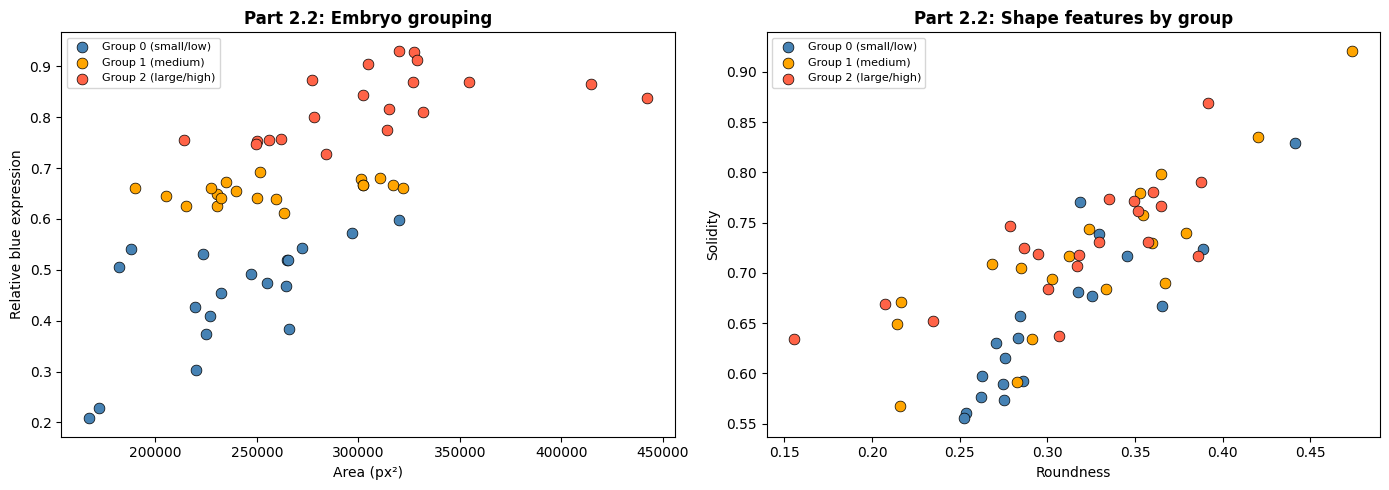

In [110]:
group_colors = {0: 'steelblue', 1: 'orange', 2: 'tomato'}
group_labels = {0: 'Group 0 (small/low)', 1: 'Group 1 (medium)', 2: 'Group 2 (large/high)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: area vs rel_blue
for g in [0, 1, 2]:
    sub = df_features[df_features['group'] == g]
    axes[0].scatter(sub['area'], sub['rel_blue'], c=group_colors[g], label=group_labels[g], s=60, edgecolors='k', linewidths=0.5)
axes[0].set_xlabel('Area (px²)')
axes[0].set_ylabel('Relative blue expression')
axes[0].set_title('Part 2.2: Embryo grouping', fontweight='bold')
axes[0].legend(fontsize=8)

# Scatter: roundness vs solidity
for g in [0, 1, 2]:
    sub = df_features[df_features['group'] == g]
    axes[1].scatter(sub['roundness'], sub['solidity'], c=group_colors[g], label=group_labels[g], s=60, edgecolors='k', linewidths=0.5)
axes[1].set_xlabel('Roundness')
axes[1].set_ylabel('Solidity')
axes[1].set_title('Part 2.2: Shape features by group', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('grouping_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

### Part 3.1  Texture features and HOG


In [111]:
def compute_texture_features(rgb, mask):

    if mask.sum() == 0:
        return {'mean': 0, 'std': 0, 'uniformity': 0}

    # Convert to grayscale [0,1]
    maxval = 65535.0 if rgb.dtype == np.uint16 else 255.0
    grey = rgb.mean(axis=2).astype(float) / maxval
    pixels = grey[mask]
    mean = float(pixels.mean())
    std = float(pixels.std())

    # Uniformity: normalised histogram squared and summed
    hist, _ = np.histogram(pixels, bins=256, range=(0, 1))
    p = hist / hist.sum() # normalise to cell area
    uniformity = float(np.sum(p ** 2))

    return {'mean': mean, 'std': std, 'uniformity': uniformity}

# --- Compute for all embryos ---
texture_rows = []
for name in names:
    rgb = results[name]['rgb']
    embryo_mask = results[name]['mask']
    blue_mask = results[name]['blue_mask']
    # Non-blue region = embryo mask minus blue mask
    non_blue_mask = embryo_mask & ~blue_mask
    tex_blue = compute_texture_features(rgb, blue_mask)
    tex_non_blue = compute_texture_features(rgb, non_blue_mask)

    texture_rows.append({
        'embryo':name,
        'group':results[name]['group'],
        # Blue region
        'blue_mean':tex_blue['mean'],
        'blue_std': tex_blue['std'],
        'blue_uniformity': tex_blue['uniformity'],
        # Non-blue region
        'rest_mean':tex_non_blue['mean'],
        'rest_std':tex_non_blue['std'],
        'rest_uniformity': tex_non_blue['uniformity'],
    })

df_texture = pd.DataFrame(texture_rows).set_index('embryo')
print('Texture features:')
print(df_texture.round(4).to_string())

Texture features:
              group  blue_mean  blue_std  blue_uniformity  rest_mean  rest_std  rest_uniformity
embryo                                                                                         
w8t1t2_d7_01      1     0.2806    0.1134           0.0142     0.6450    0.1423           0.0114
w8t1t2_d7_02      0     0.3173    0.1232           0.0109     0.6069    0.0941           0.0174
w8t1t2_d7_03      0     0.3984    0.1633           0.0070     0.6854    0.1119           0.0133
w8t1t2_d7_04      2     0.2715    0.0914           0.0136     0.5546    0.1515           0.0108
w8t1t2_d7_05      1     0.4294    0.1476           0.0078     0.5397    0.1169           0.0110
w8t1t2_d7_06      1     0.3408    0.1425           0.0094     0.5883    0.1026           0.0143
w8t1t2_d7_07      0     0.3611    0.1101           0.0119     0.6474    0.1103           0.0110
w8t1t2_d7_08      0     0.3408    0.1391           0.0083     0.6239    0.1234           0.0113
w8t1t2_d7_09      0   

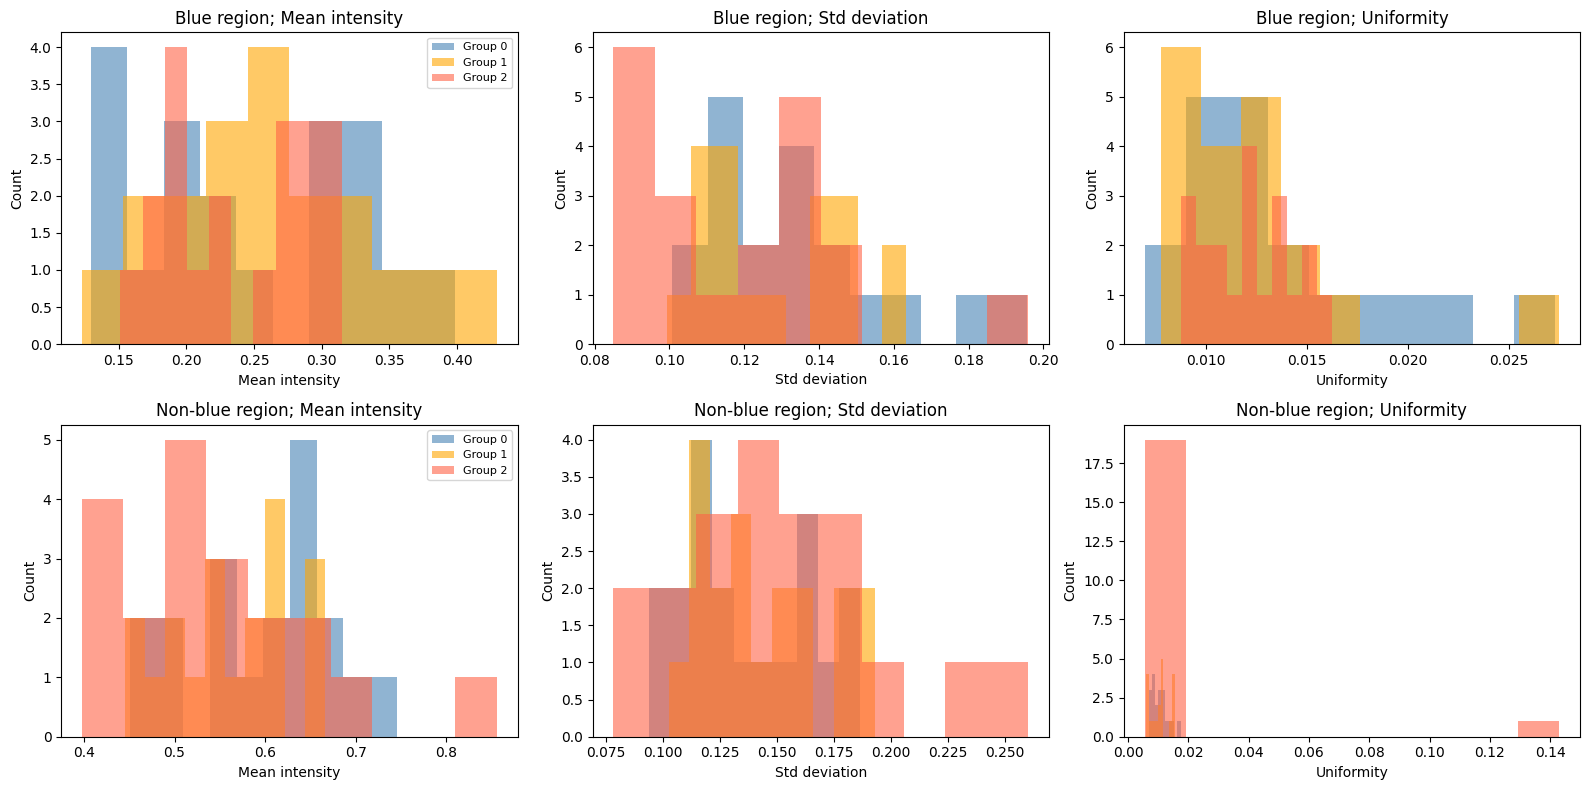

In [113]:
# Visual
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

group_colors = {0: 'steelblue', 1: 'orange', 2: 'tomato'}
features = ['mean', 'std', 'uniformity']
labels = ['Mean intensity', 'Std deviation', 'Uniformity']

for col, (feat, label) in enumerate(zip(features, labels)):

    for g in [0, 1, 2]:
        vals = df_texture[df_texture['group'] == g][f'blue_{feat}'].values
        axes[0, col].hist(vals, bins=10, alpha=0.6, color=group_colors[g], label=f'Group {g}')
    axes[0, col].set_title(f'Blue region; {label}')
    axes[0, col].set_xlabel(label)
    axes[0, col].set_ylabel('Count')
    if col == 0:
        axes[0, col].legend(fontsize=8)

    # Non-blue region 
    for g in [0, 1, 2]:
        vals = df_texture[df_texture['group'] == g][f'rest_{feat}'].values
        axes[1, col].hist(vals, bins=10, alpha=0.6, color=group_colors[g], label=f'Group {g}')
    axes[1, col].set_title(f'Non-blue region; {label}')
    axes[1, col].set_xlabel(label)
    axes[1, col].set_ylabel('Count')
    if col == 0:
        axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig('texture_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

### Part 3.2  HOG Features

In [114]:
HOG_SIZE = (128, 128) # resize all crops to this for HOG
HOG_CELLS = [16, 64] # two cell sizes as required

def compute_hog_features(rgb, mask, cell_size, visualise=False):
    # Crop to bounding box of mask
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return np.zeros(1), None

    r0, r1 = rows.min(), rows.max()
    c0, c1 = cols.min(), cols.max()
    # Crop RGB and mask
    crop_rgb = rgb[r0:r1+1, c0:c1+1]
    crop_mask = mask[r0:r1+1, c0:c1+1]
    # Apply mask — set non-region pixels to 0
    crop_rgb = crop_rgb.copy().astype(float)
    for ch in range(crop_rgb.shape[2]):
        crop_rgb[:,:,ch][~crop_mask] = 0
    # Normalise and resize to HOG_SIZE
    maxval = 65535.0 if rgb.dtype == np.uint16 else 255.0
    crop_f = crop_rgb / maxval
    crop_res = sk_resize(crop_f, (*HOG_SIZE, 3), anti_aliasing=True)

    # Compute HOG
    pixels_per_cell = (cell_size, cell_size)
    cells_per_block = (2, 2)

    if visualise:
        feat_vec, hog_img = hog( crop_res, orientations=9,  pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, visualize=True, channel_axis=-1)
        return feat_vec, hog_img
    else:
        feat_vec = hog(crop_res,orientations=9, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, visualize=False, channel_axis=-1)
        return feat_vec, None

# Compute HOG for all embryos, both regions, both cell sizes 
hog_features = {}   # {name: {'blue_16': vec, 'blue_64': vec, 'whole_16': vec, 'whole_64': vec}}

for name in names:
    rgb  = results[name]['rgb']
    embryo_mask = results[name]['mask']
    blue_mask = results[name]['blue_mask']

    hog_features[name] = {}
    for cell_size in HOG_CELLS:
        vec_blue, _ = compute_hog_features(rgb, blue_mask,   cell_size)
        vec_whole, _ = compute_hog_features(rgb, embryo_mask, cell_size)
        hog_features[name][f'blue_{cell_size}']  = vec_blue
        hog_features[name][f'whole_{cell_size}'] = vec_whole

    print(f'{name}: HOG done; '
          f'blue_16={hog_features[name]["blue_16"].shape}, '
          f'whole_64={hog_features[name]["whole_64"].shape}')


w8t1t2_d7_01: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_02: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_03: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_04: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_05: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_06: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_07: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_08: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_09: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_10: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_11: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_12: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_13: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_14: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_15: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_16: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_17: HOG done; blue_16=(1764,), whole_64=(36,)
w8t1t2_d7_18: HOG done; blue_16=(1764,), whole_6

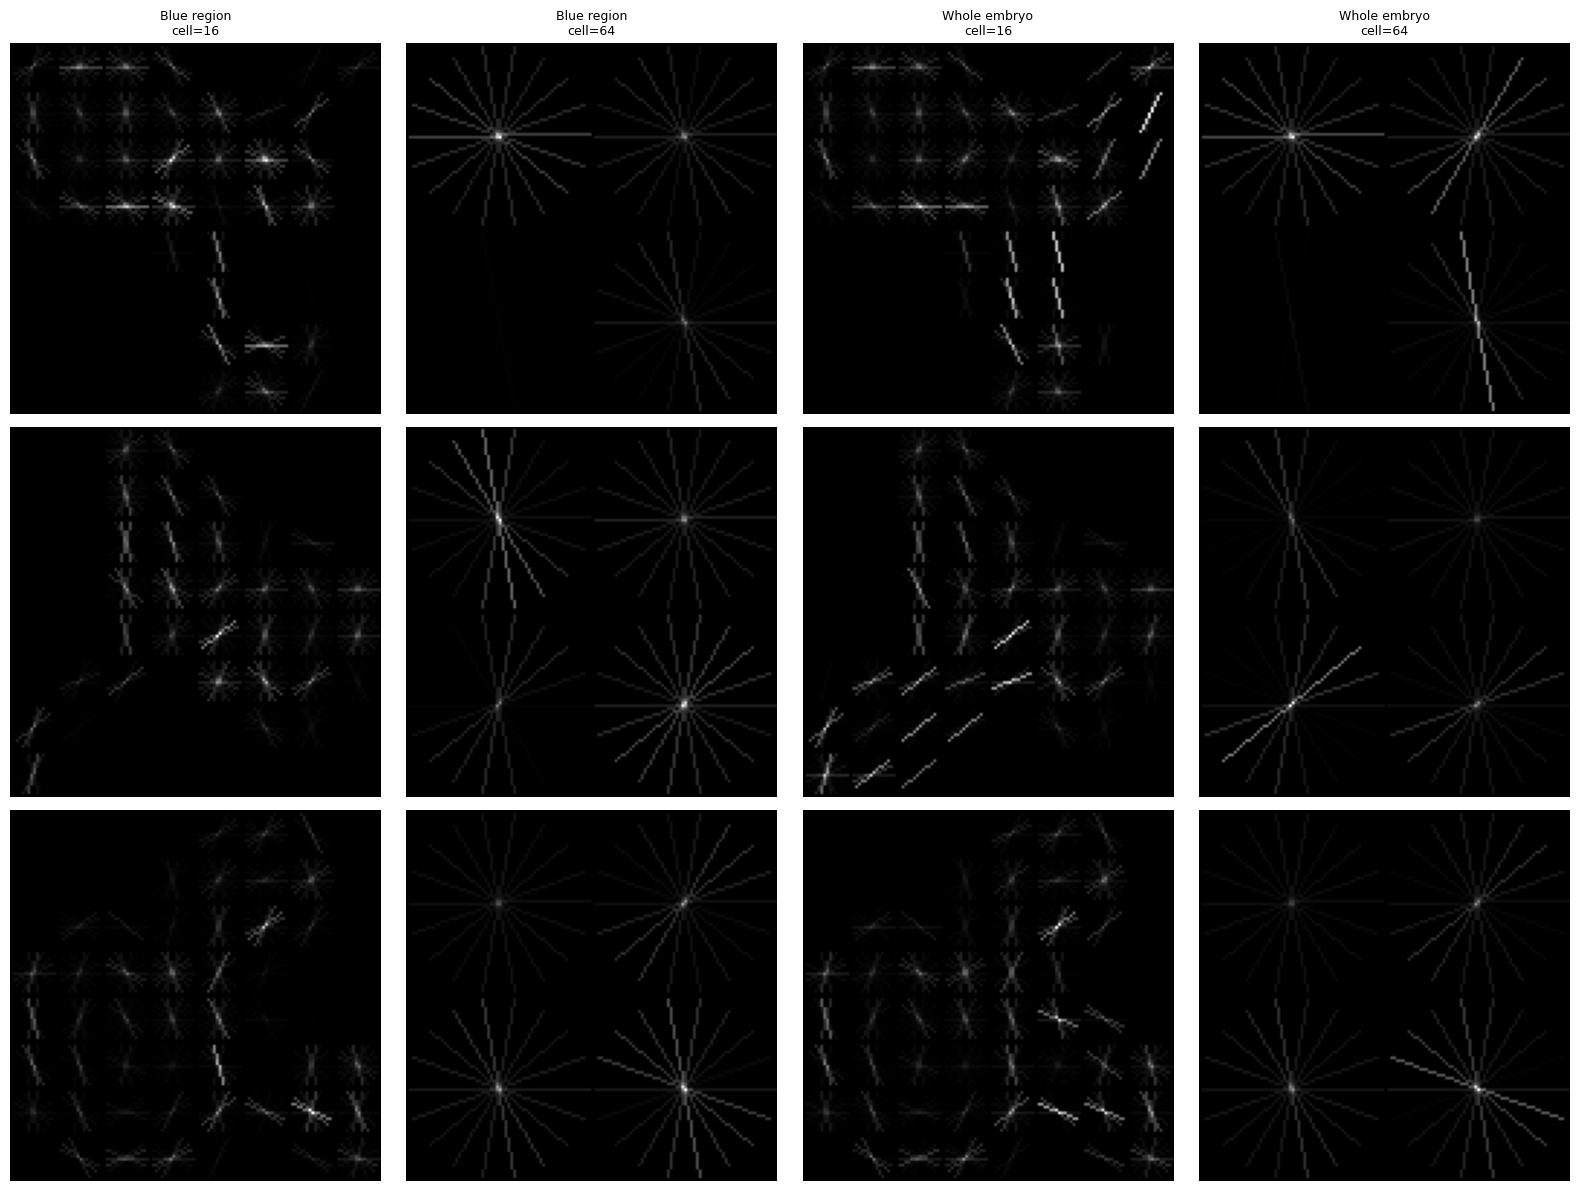

In [115]:
sample_per_group = [ df_features[df_features['group'] == g].index[0] for g in [0, 1, 2]]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ['Blue region\ncell=16', 'Blue region\ncell=64',
              'Whole embryo\ncell=16', 'Whole embryo\ncell=64']

for row, name in enumerate(sample_per_group):
    rgb = results[name]['rgb']
    embryo_mask = results[name]['mask']
    blue_mask = results[name]['blue_mask']
    g = results[name]['group']

    configs = [ (blue_mask,16), (blue_mask,64), (embryo_mask, 16), (embryo_mask, 64),]

    for col, (mask, cell_size) in enumerate(configs):
        _, hog_img = compute_hog_features(rgb, mask, cell_size, visualise=True)

        axes[row, col].imshow(hog_img, cmap='gray')
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(
                f'Group {g}\n{name.replace("w8t1t2_d7_","")}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('hog_appendix.png', dpi=100, bbox_inches='tight')
plt.show()

## Part 4 SVM Classification

In [116]:
# Features: HOG, Texture, Shape, Combined
# Split: 80% train / 20% test

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Labels
y = np.array([results[name]['group'] for name in names])
print(f'Classes: {np.unique(y)}, distribution: {np.bincount(y)}')

# 1. HOG features (blue region, cell=16 — most informative)
X_hog_blue_16  = np.array([hog_features[name]['blue_16']  for name in names])
X_hog_blue_64  = np.array([hog_features[name]['blue_64']  for name in names])
X_hog_whole_16 = np.array([hog_features[name]['whole_16'] for name in names])
X_hog_whole_64 = np.array([hog_features[name]['whole_64'] for name in names])
# Concatenate all HOG variants into one HOG feature set
X_hog = np.hstack([X_hog_blue_16, X_hog_blue_64,
                   X_hog_whole_16, X_hog_whole_64])

# 2. Texture features
X_texture = np.array([
    [
        df_texture.loc[name, 'blue_mean'],
        df_texture.loc[name, 'blue_std'],
        df_texture.loc[name, 'blue_uniformity'],
        df_texture.loc[name, 'rest_mean'],
        df_texture.loc[name, 'rest_std'],
        df_texture.loc[name, 'rest_uniformity'],
    ]
    for name in names
])

# 3. Shape features
X_shape = np.array([
    [
        df_features.loc[name, 'area'],
        df_features.loc[name, 'perimeter'],
        df_features.loc[name, 'roundness'],
        df_features.loc[name, 'solidity'],
        df_features.loc[name, 'abs_blue'],
        df_features.loc[name, 'rel_blue'],
    ]
    for name in names
])

# 4. Combined
X_combined = np.hstack([X_hog, X_texture, X_shape])

print(f'HOG feature vector size:      {X_hog.shape}')
print(f'Texture feature vector size:  {X_texture.shape}')
print(f'Shape feature vector size:    {X_shape.shape}')
print(f'Combined feature vector size: {X_combined.shape}')

Classes: [0 1 2], distribution: [19 19 20]
HOG feature vector size:      (58, 3600)
Texture feature vector size:  (58, 6)
Shape feature vector size:    (58, 6)
Combined feature vector size: (58, 3612)


In [117]:
def run_svm(X, y, feature_name, random_state=42):

    # Train/test split (80/20, stratified to keep class balance)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)
    # Normalise features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    # Train SVM
    clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=random_state)
    clf.fit(X_train, y_train)
    # Predict
    y_pred = clf.predict(X_test)
    # Report
    print(f'  {feature_name}')
    print(f'Train size: {len(y_train)}, Test size: {len(y_test)}')
    print(f'Class distribution in test: {np.bincount(y_test)}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Group 0', 'Group 1', 'Group 2'], zero_division=0))

    return y_test, y_pred, clf, scaler

### Part 4.1 SVM on HOG features

In [118]:
y_test_hog, y_pred_hog, clf_hog, _ = run_svm( X_hog, y, 'SVM: HOG features')

  SVM: HOG features
Train size: 46, Test size: 12
Class distribution in test: [4 4 4]

              precision    recall  f1-score   support

     Group 0       0.00      0.00      0.00         4
     Group 1       0.00      0.00      0.00         4
     Group 2       0.30      0.75      0.43         4

    accuracy                           0.25        12
   macro avg       0.10      0.25      0.14        12
weighted avg       0.10      0.25      0.14        12



### Part 4.2 SVM on Texture features

In [119]:
y_test_tex, y_pred_tex, clf_tex, _ = run_svm( X_texture, y, 'SVM: Texture features')

  SVM: Texture features
Train size: 46, Test size: 12
Class distribution in test: [4 4 4]

              precision    recall  f1-score   support

     Group 0       0.33      0.25      0.29         4
     Group 1       0.25      0.25      0.25         4
     Group 2       0.60      0.75      0.67         4

    accuracy                           0.42        12
   macro avg       0.39      0.42      0.40        12
weighted avg       0.39      0.42      0.40        12



### Part 4.3 SVM on Shape features

In [120]:
y_test_shp, y_pred_shp, clf_shp, _ = run_svm( X_shape, y, 'SVM: Shape features')

  SVM: Shape features
Train size: 46, Test size: 12
Class distribution in test: [4 4 4]

              precision    recall  f1-score   support

     Group 0       1.00      1.00      1.00         4
     Group 1       1.00      1.00      1.00         4
     Group 2       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



### Part 4.4 SVM on Combined features

In [121]:
y_test_com, y_pred_com, clf_com, _ = run_svm(X_combined, y, 'SVM: Combined features')

  SVM: Combined features
Train size: 46, Test size: 12
Class distribution in test: [4 4 4]

              precision    recall  f1-score   support

     Group 0       0.00      0.00      0.00         4
     Group 1       0.00      0.00      0.00         4
     Group 2       0.36      1.00      0.53         4

    accuracy                           0.33        12
   macro avg       0.12      0.33      0.18        12
weighted avg       0.12      0.33      0.18        12



### Part 4.5 Confusion matrices for all four classifiers

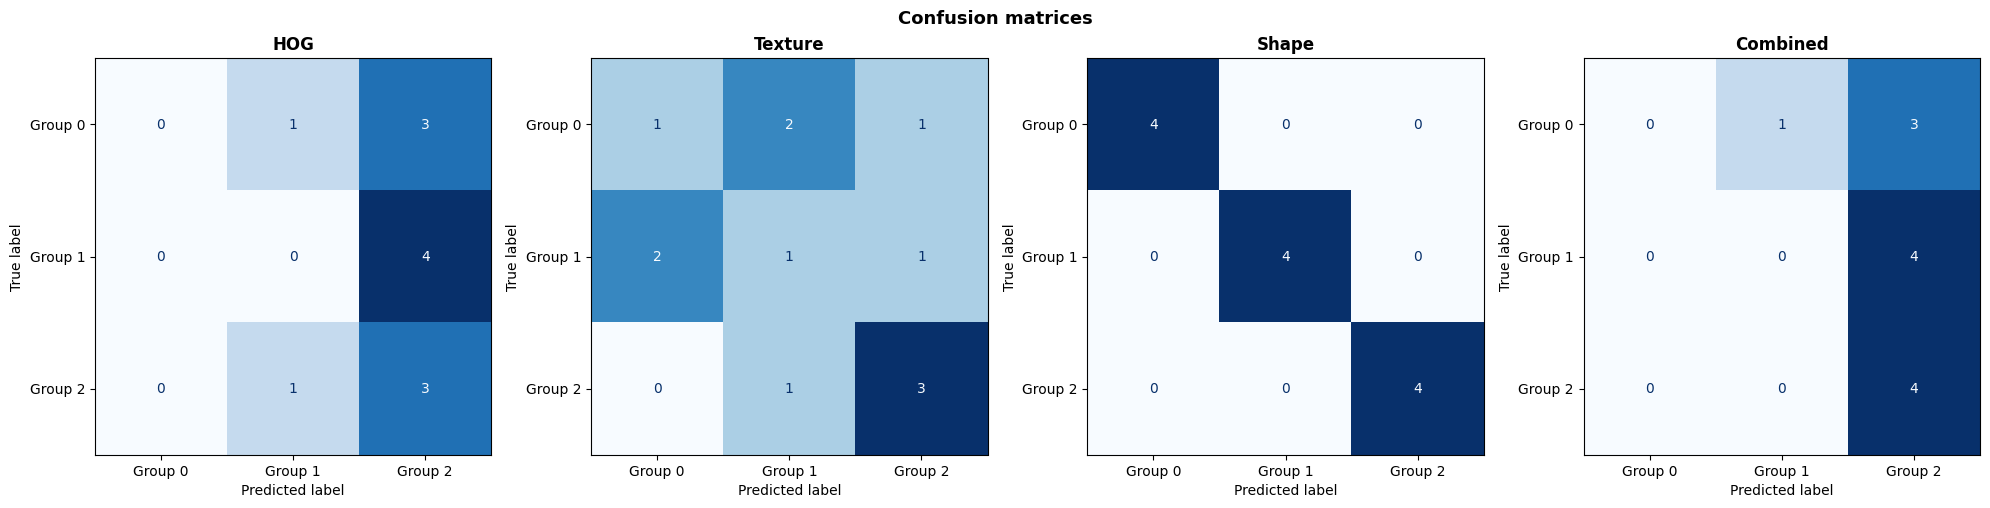

In [122]:

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion matrices', fontweight='bold', fontsize=13)

configs = [
    (y_test_hog, y_pred_hog, 'HOG'),
    (y_test_tex, y_pred_tex, 'Texture'),
    (y_test_shp, y_pred_shp, 'Shape'),
    (y_test_com, y_pred_com, 'Combined'),
]

for ax, (y_t, y_p, title) in zip(axes, configs):
    cm = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Group 0', 'Group 1', 'Group 2'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

### Part 4.6 Texture classification

In [123]:
from sklearn.metrics import accuracy_score

acc_tex = accuracy_score(y_test_tex, y_pred_tex)
acc_com = accuracy_score(y_test_com, y_pred_com)

print(f'Texture SVM accuracy:  {acc_tex*100:.1f}%')
print(f'Combined SVM accuracy: {acc_com*100:.1f}%')

# Show texture predictions vs true groups
print('True group vs Texture prediction (test set):')
print(f'{"True":>8} {"Predicted":>12} {"Match":>8}')
print('-' * 32)
for true, pred in zip(y_test_tex, y_pred_tex):
    match = 'Yip' if true == pred else 'Nope'
    print(f'{true:>8} {pred:>12} {match:>8}')

Texture SVM accuracy:  41.7%
Combined SVM accuracy: 33.3%
True group vs Texture prediction (test set):
    True    Predicted    Match
--------------------------------
       0            2     Nope
       2            2      Yip
       1            0     Nope
       1            2     Nope
       2            2      Yip
       0            1     Nope
       2            1     Nope
       0            0      Yip
       1            1      Yip
       1            0     Nope
       2            2      Yip
       0            1     Nope


### Part 4.7 Assessment of feature sets

Feature set    Accuracy   F1 macro
-----------------------------------
HOG               25.0%      14.3%
Texture           41.7%      40.1%
Shape            100.0%     100.0%
Combined          33.3%      17.8%


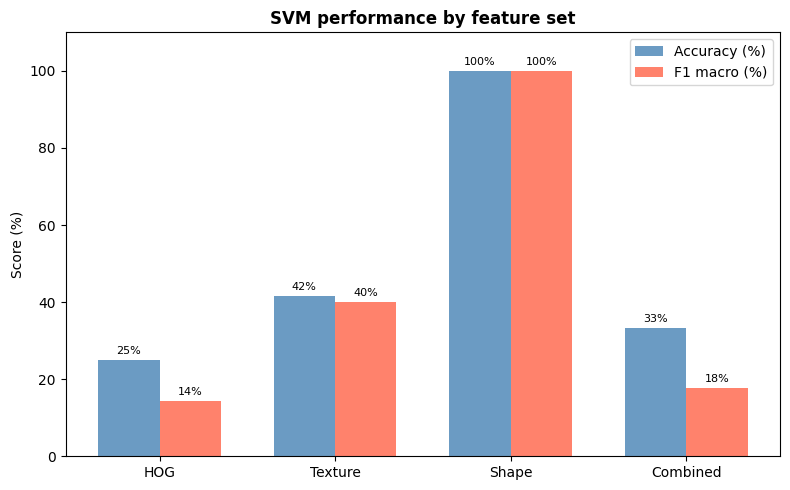

In [125]:
from sklearn.metrics import f1_score

results_summary = {}
for y_t, y_p, fname in [
    (y_test_hog, y_pred_hog, 'HOG'),
    (y_test_tex, y_pred_tex, 'Texture'),
    (y_test_shp, y_pred_shp, 'Shape'),
    (y_test_com, y_pred_com, 'Combined'),
]:
    acc = accuracy_score(y_t, y_p)
    f1 = f1_score(y_t, y_p, average='macro', zero_division=0)
    results_summary[fname] = {'accuracy': acc, 'f1_macro': f1}

print(f'{"Feature set":<12} {"Accuracy":>10} {"F1 macro":>10}')
print('-' * 35)
for fname, metrics in results_summary.items():
    print(f'{fname:<12} {metrics["accuracy"]*100:>9.1f}% 'f'{metrics["f1_macro"]*100:>9.1f}%')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
fnames = list(results_summary.keys())
accs = [results_summary[f]['accuracy'] * 100 for f in fnames]
f1s = [results_summary[f]['f1_macro'] * 100  for f in fnames]
x = np.arange(len(fnames))
w = 0.35
b1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, f1s, w, label='F1 macro (%)', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(fnames)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('SVM performance by feature set', fontweight='bold')
ax.legend()
ax.bar_label(b1, fmt='%.0f%%', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.0f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('svm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()